# Task A: Shunt Valve Artifact Detection
3D U-Net pipeline — designed for Google Colab (T4 GPU)

**Sections:**
1. Install dependencies
2. Mount Google Drive & set paths
3. Config
4. Transforms
5. Model
6. Train
7. Evaluate (local val split)
8. Predict on test set

In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

## 1. Install dependencies

In [4]:
!pip install -q monai nibabel scipy scikit-learn tqdm
# torch + torchvision are pre-installed on Colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.0 MB/s eta 0:00:00


## 2. Mount Google Drive & set paths

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from pathlib import Path

# ── Edit these paths to match your Drive layout ──────────────────────────────
TRAIN_DATA_DIR = Path('/content/drive/MyDrive/MIA/proj2_preprocessed/train')   # subjXXX/ folders with images + masks
TEST_DATA_DIR  = Path('/content/drive/MyDrive/MIA/proj2_preprocessed/test')    # subjXXX/ folders, images only
ORIGINAL_DATA_DIR = Path('/content/drive/MyDrive/MIA/original_data/Train')
OUTPUT_DIR     = Path('/content/drive/MyDrive/MIA/runs/taskA')  # checkpoints saved here
PRED_DIR       = Path('/content/drive/MyDrive/MIA/predictions/taskA')  # subjXXX_taskA.nii.gz
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)
print('Paths OK')

Paths OK


## 3. Imports & Config

In [7]:
import os, json, random
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm          # notebook-friendly progress bars
from scipy.ndimage import zoom

from monai.networks.nets import UNet
from monai.data import pad_list_data_collate
from monai.data import Dataset
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
    ScaleIntensityRangePercentilesd, CropForegroundd,
    RandSpatialCropd, RandFlipd, RandRotate90d,
    RandScaleIntensityd, RandShiftIntensityd,
    EnsureTyped, Orientationd, AsDiscrete
)
import monai.transforms as mt
from monai.data import CacheDataset, decollate_batch
from monai.inferers import sliding_window_inference

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [8]:

# ── Hyperparameters — tweak here ─────────────────────────────────────────────
PATCH_SIZE    = (96, 96, 96)   # training crop; reduce to (80,80,80) if OOM, reducing it made DICE loss worse
SPACING       = (1 ,1, 1)
BATCH_SIZE    = 4              # reduce to 1 if OOM, bumped up to num_samples (4) for now
NUM_WORKERS   = 2
MAX_EPOCHS    = 100
VAL_INTERVAL  = 5
LR            = 2e-4
WEIGHT_DECAY  = 1e-5
POS_NEG_RATIO = 4              # foreground:background patch ratio
NUM_SAMPLES   = 4              # patches per volume per step
SW_BATCH_SIZE = 2              # sliding-window sub-batch (reduce if OOM)
OVERLAP       = 0.25
CHANNELS      = (16,32,64,128)
STRIDES       = (2, 2, 2,2)
NUM_RES_UNITS = 1
DROPOUT       = 0.1
VAL_FRAC      = 0.15
SEED          = 42
AMP           = True           # mixed precision — keep True on T4
# ─────────────────────────────────────────────────────────────────────────────
#Change spacing from 1 to 0.75, increased num of epochs, increased channels for deeper network, and increased pos_neg_ratio from 4 to 16 for task B, that gave validation loss of 0.530. changed parameters to increase this
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Config set.')

Config set.


## 4. Data utilities & Transforms

In [9]:
def get_subject_ids(data_dir):
    return sorted([d.name for d in Path(data_dir).iterdir()
                   if d.is_dir() and d.name.startswith('subj')])

def build_data_dicts(data_dir, subject_ids, has_labels=True):
    dicts = []
    for sid in subject_ids:
        entry = {'image': str(Path(data_dir) / sid / f'{sid}_image_preprocessed.nii.gz')}
        if has_labels:
            entry['label'] = str(Path(data_dir) / sid / f'{sid}_image_artifact.nii.gz')
        dicts.append(entry)
    return dicts

def train_val_split(subject_ids, val_frac=0.15, seed=42):
    ids = list(subject_ids)
    random.Random(seed).shuffle(ids)
    n_val = max(1, int(len(ids) * val_frac))
    return ids[n_val:], ids[:n_val]

# ── Verify a few paths exist ──────────────────────────────────────────────────
all_ids = get_subject_ids(TRAIN_DATA_DIR)
print(f'Found {len(all_ids)} training subjects: {all_ids[:3]} ...')
train_ids, val_ids = train_val_split(all_ids, VAL_FRAC, SEED)
print(f'Train: {len(train_ids)} | Val: {len(val_ids)}')

Found 160 training subjects: ['subj001', 'subj002', 'subj003'] ...
Train: 136 | Val: 24


In [11]:

def get_train_transforms():
    return Compose([
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys=['image', 'label']),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(keys=['image', 'label'], pixdim=SPACING,
                 mode=('bilinear', 'nearest')),
        CropForegroundd(keys=['image', 'label'], source_key='image'),
        ScaleIntensityRangePercentilesd(
            keys=['image'], lower=0.5, upper=99.5,
            b_min=0.0, b_max=1.0, clip=True),
        RandSpatialCropd(keys=['image', 'label'],
                         roi_size=PATCH_SIZE, random_size=False),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
        RandFlipd(keys=['image', 'label'], prob=0.3, spatial_axis=1),
        RandFlipd(keys=['image', 'label'], prob=0.3, spatial_axis=2),
        RandRotate90d(keys=['image', 'label'], prob=0.3, max_k=3),
        RandScaleIntensityd(keys=['image'], factors=0.1, prob=0.5),
        RandShiftIntensityd(keys=['image'], offsets=0.1, prob=0.5),
        EnsureTyped(keys=['image', 'label']),
    ])

def get_val_transforms():
  return Compose([
      LoadImaged(keys=['image', 'label']),
      EnsureChannelFirstd(keys=['image', 'label']),
      Orientationd(keys=['image', 'label'], axcodes='RAS'),
      Spacingd(keys=['image', 'label'], pixdim=SPACING,
                mode=('bilinear', 'nearest')),
      CropForegroundd(keys=['image', 'label'], source_key='image'),
      ScaleIntensityRangePercentilesd(
          keys=['image'], lower=0.5, upper=99.5,
          b_min=0.0, b_max=1.0, clip=True),
      EnsureTyped(keys=['image', 'label']),
  ])

print('Transforms defined.')

train_dicts = build_data_dicts(TRAIN_DATA_DIR, train_ids, has_labels=True)
val_dicts   = build_data_dicts(TRAIN_DATA_DIR, val_ids,   has_labels=True)

train_ds = Dataset(train_dicts, transform=get_train_transforms())

print('Building validation cache...')
val_ds = CacheDataset(val_dicts, transform=get_val_transforms(),
                      cache_rate=1.0, num_workers=NUM_WORKERS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS)  # no collate_fn needed
val_loader   = DataLoader(val_ds, batch_size=1,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f'Loaders ready — {len(train_loader)} train batches, {len(val_loader)} val volumes')

Transforms defined.
Building validation cache...


Loading dataset: 100%|██████████| 24/24 [00:22<00:00,  1.08it/s]

Loaders ready — 34 train batches, 24 val volumes


## 5. Model

In [12]:
def build_model():
    return UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=2,
        channels=CHANNELS,
        strides=STRIDES,
        num_res_units=NUM_RES_UNITS,
        dropout=DROPOUT,
    ).to(device)

model = build_model()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

/usr/local/lib/python3.12/dist-packages/monai/networks/nets/unet.py:130: UserWarning: `len(strides) > len(channels) - 1`, the last 1 values of strides will not be used.
  warnings.warn(f"`len(strides) > len(channels) - 1`, the last {delta} values of strides will not be used.")


Model parameters: 599,001


## 6. Train

In [ ]:
loss_fn    = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
                 optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=AMP)
dice_metric  = DiceMetric(include_background=False, reduction='mean')
post_pred    = AsDiscrete(argmax=True, to_onehot=2)
post_label   = AsDiscrete(to_onehot=2)

best_val_dice = 0.0
history = {'train_loss': [], 'val_dice': []}

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        imgs   = batch['image'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=AMP):
            loss = loss_fn(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    # ── Validate ───────────────────────────────────────────────────────────────
    if epoch % VAL_INTERVAL == 0:
        model.eval()
        dice_metric.reset()
        with torch.no_grad():
            for val_batch in val_loader:
                val_img   = val_batch['image'].to(device)
                val_label = val_batch['label'].to(device)
                val_logits = sliding_window_inference(
                    val_img, PATCH_SIZE, SW_BATCH_SIZE, model, overlap=OVERLAP)
                preds  = [post_pred(val_logits[i])  for i in range(val_logits.shape[0])]
                labels = [post_label(val_label[i])  for i in range(val_label.shape[0])]
                dice_metric(y_pred=preds, y=labels)

        val_dice = dice_metric.aggregate().item()
        history['val_dice'].append(val_dice)
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | loss={avg_loss:.4f} | val Dice={val_dice:.4f}')

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pt')
            print(f'  ✓ Best model saved (Dice={best_val_dice:.4f})')
    else:
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | loss={avg_loss:.4f}')

torch.save(model.state_dict(), OUTPUT_DIR / 'last_model.pt')
with open(OUTPUT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nTraining complete. Best val Dice: {best_val_dice:.4f}')

Epoch   5/100 | loss=0.7634 | val Dice=0.0000
Epoch  10/100 | loss=0.5834 | val Dice=0.0000
Epoch  15/100 | loss=0.5308 | val Dice=0.2266
  ✓ Best model saved (Dice=0.2266)
Epoch  20/100 | loss=0.4887 | val Dice=0.3314
  ✓ Best model saved (Dice=0.3314)
Epoch  25/100 | loss=0.4774 | val Dice=0.5084
  ✓ Best model saved (Dice=0.5084)
Epoch  30/100 | loss=0.4472 | val Dice=0.7343
  ✓ Best model saved (Dice=0.7343)
Epoch  35/100 | loss=0.4295 | val Dice=0.4853
Epoch  40/100 | loss=0.4137 | val Dice=0.8331
  ✓ Best model saved (Dice=0.8331)
Epoch  45/100 | loss=0.4213 | val Dice=0.8169
Epoch  50/100 | loss=0.3809 | val Dice=0.8457
  ✓ Best model saved (Dice=0.8457)
Epoch  55/100 | loss=0.3822 | val Dice=0.8418
Epoch  60/100 | loss=0.4179 | val Dice=0.8400
Epoch  65/100 | loss=0.3811 | val Dice=0.8486
  ✓ Best model saved (Dice=0.8486)
Epoch  70/100 | loss=0.4027 | val Dice=0.8183
Epoch  75/100 | loss=0.3899 | val Dice=0.8639
  ✓ Best model saved (Dice=0.8639)
Epoch  80/100 | loss=0.4074 | 

## 7. Plot training curves

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'])
ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('DiceCE Loss')

val_epochs = list(range(VAL_INTERVAL, MAX_EPOCHS + 1, VAL_INTERVAL))
ax2.plot(val_epochs, history['val_dice'], marker='o')
ax2.set_title('Val Dice (Task A)'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice')
ax2.axhline(best_val_dice, color='r', linestyle='--', label=f'Best={best_val_dice:.4f}')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()

## 8. Predict on test set

In [ ]:
!pip install antspyx

In [27]:
test_pre = mt.Compose([
    mt.LoadImage(image_only=True),
    mt.EnsureChannelFirst(),
    mt.Orientation(axcodes='RAS'),
    mt.Spacing(pixdim=SPACING, mode='bilinear'),
    mt.ScaleIntensityRangePercentiles(
        lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True),
    mt.EnsureType(),
])

In [23]:
import ants
from scipy import ndimage

def keep_largest_component(mask):
    labeled, n = ndimage.label(mask)
    if n == 0:
        return mask
    sizes = ndimage.sum(mask, labeled, range(1, n + 1))
    largest = np.argmax(sizes) + 1
    return (labeled == largest).astype(np.uint8)

# Load best checkpoint
model = build_model()
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pt', map_location=device))
model.eval()
print('Best model loaded.')

test_ids   = get_subject_ids(TEST_DATA_DIR)
test_dicts = build_data_dicts(TEST_DATA_DIR, test_ids, has_labels=False)
print(f'Test subjects: {len(test_ids)}')

for entry in tqdm(test_dicts, desc='Predicting'):
    image_path = entry['image']
    sid = Path(image_path).parent.name

    # need to warp back to original format
    native_path = str(ORIGINAL_DATA_DIR / sid / f'{sid}_image.nii.gz')
    native_img  = ants.image_read(native_path)

    # Load transform saved during preprocessing
    transform_path = str(TEST_DATA_DIR / sid / f'{sid}_image_transform_0.mat')

    # Preprocess and run inference
    img_t = test_pre(image_path).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = sliding_window_inference(
            img_t, PATCH_SIZE, SW_BATCH_SIZE, model, overlap=OVERLAP)

    # Argmax → numpy → largest component
    pred_np = logits.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)
    pred_np = keep_largest_component(pred_np)

    # Load preprocessed image as ANTs image to get its space
    preprocessed_ants = ants.image_read(image_path)

    # Resize pred back to preprocessed space (accounts for Spacingd resampling)
    zoom_factors = [preprocessed_ants.shape[i] / pred_np.shape[i] for i in range(3)]
    pred_preprocessed = zoom(pred_np, zoom_factors, order=0).astype(np.float32)

    # Wrap pred as ANTs image in preprocessed space
    pred_ants = ants.from_numpy(
        pred_preprocessed,
        origin=preprocessed_ants.origin,
        spacing=preprocessed_ants.spacing,
        direction=preprocessed_ants.direction
    )

    # Apply INVERSE transform to warp back to native space
    pred_native = ants.apply_transforms(
        fixed=native_img,
        moving=pred_ants,
        transformlist=[transform_path],
        whichtoinvert=[True],          # ← inverts the rigid transform
        interpolator='nearestNeighbor' # ← keeps binary mask binary
    )

    # Save in native space
    pred_final = pred_native.numpy().astype(np.uint8)
    orig_nib   = nib.load(native_path)
    out_img    = nib.Nifti1Image(pred_final, orig_nib.affine, orig_nib.header)
    out_path   = PRED_DIR / f'{sid}_taskA.nii.gz'
    nib.save(out_img, str(out_path))

print(f'\nAll predictions saved to: {PRED_DIR}')
print('Files:', sorted([p.name for p in PRED_DIR.glob('*_taskA.nii.gz')]))

RuntimeError: Error(s) in loading state_dict for UNet:
	Missing key(s) in state_dict: "model.1.submodule.1.submodule.1.submodule.conv.unit0.conv.weight", "model.1.submodule.1.submodule.1.submodule.conv.unit0.conv.bias", "model.1.submodule.1.submodule.1.submodule.conv.unit0.adn.A.weight", "model.1.submodule.1.submodule.1.submodule.residual.weight", "model.1.submodule.1.submodule.1.submodule.residual.bias". 
	Unexpected key(s) in state_dict: "model.0.conv.unit1.conv.weight", "model.0.conv.unit1.conv.bias", "model.0.conv.unit1.adn.A.weight", "model.1.submodule.0.conv.unit1.conv.weight", "model.1.submodule.0.conv.unit1.conv.bias", "model.1.submodule.0.conv.unit1.adn.A.weight", "model.1.submodule.1.submodule.0.conv.unit1.conv.weight", "model.1.submodule.1.submodule.0.conv.unit1.conv.bias", "model.1.submodule.1.submodule.0.conv.unit1.adn.A.weight", "model.1.submodule.1.submodule.1.submodule.0.conv.unit0.conv.weight", "model.1.submodule.1.submodule.1.submodule.0.conv.unit0.conv.bias", "model.

## 9. Quick sanity check — visualise one prediction
Plots 3 axial slices of the MRI overlaid with the predicted mask.

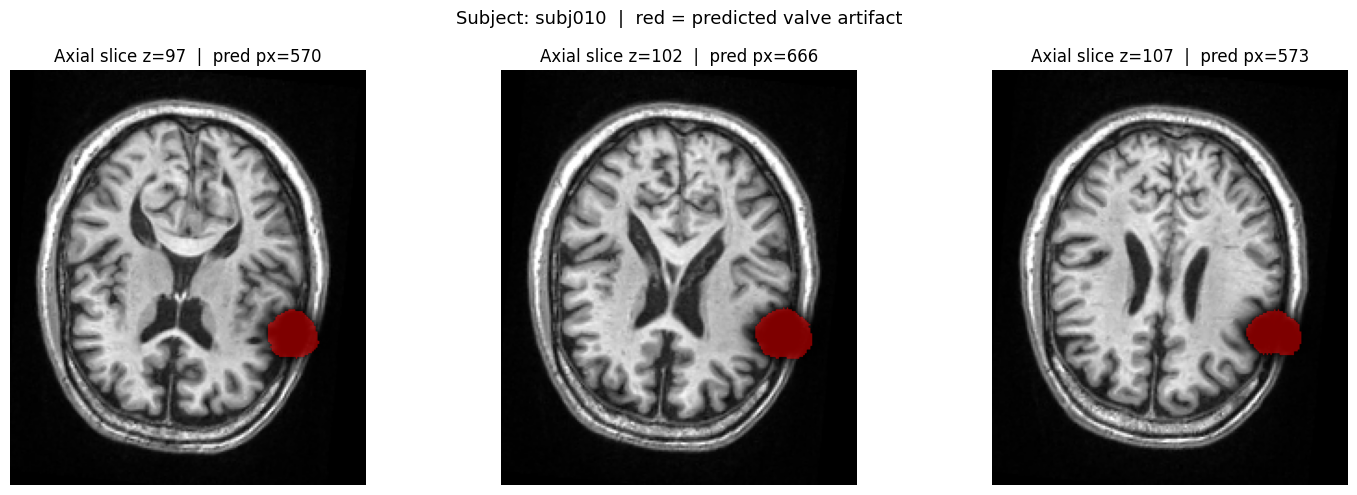

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Change this to any test subject you want to inspect
VIS_SUBJECT = "subj010"

img_vol  = nib.load(str(ORIGINAL_DATA_DIR / VIS_SUBJECT / f'{VIS_SUBJECT}_image.nii.gz')).get_fdata()
pred_vol = nib.load(str(PRED_DIR / f'{VIS_SUBJECT}_taskA.nii.gz')).get_fdata()

# Find the axial slice with most predicted foreground
foreground_per_slice = pred_vol.sum(axis=(0, 1))  # sum over X,Y for each Z
if foreground_per_slice.max() > 0:
    best_z = int(foreground_per_slice.argmax())
    slices = [max(0, best_z - 5), best_z, min(img_vol.shape[2] - 1, best_z + 5)]
else:
    # No prediction — just show middle slices
    mid = img_vol.shape[2] // 2
    slices = [mid - 10, mid, mid + 10]
    print('Warning: no foreground found in prediction!')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Subject: {VIS_SUBJECT}  |  red = predicted valve artifact', fontsize=13)

for ax, z in zip(axes, slices):
    mri_slice  = img_vol[:, :, z].T
    mask_slice = pred_vol[:, :, z].T

    vmin, vmax = np.percentile(img_vol, [1, 99])
    ax.imshow(mri_slice, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

    # Overlay mask in red with transparency
    overlay = np.zeros((*mask_slice.shape, 4))
    overlay[mask_slice > 0] = [1, 0, 0, 0.5]   # RGBA red
    ax.imshow(overlay, origin='lower')

    ax.set_title(f'Axial slice z={z}  |  pred px={int(mask_slice.sum())}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(PRED_DIR / f'{VIS_SUBJECT}_taskA_vis.png', dpi=150)
plt.show()

# TASK B

In [31]:
OUTPUT_DIR_B = Path('/content/drive/MyDrive/MIA/runs/taskB_v2')
PRED_DIR_B   = Path('/content/drive/MyDrive/MIA/predictions/taskB_v3')
VIS_DIR_B = Path('/content/drive/MyDrive/MIA/predictions/taskB_v3')
PRED_DIR_A   = Path('/content/drive/MyDrive/MIA/predictions/taskA')  # your Task A outputs
OUTPUT_DIR_B.mkdir(parents=True, exist_ok=True)
PRED_DIR_B.mkdir(parents=True, exist_ok=True)

In [14]:
def build_data_dicts_B(data_dir, subject_ids, has_labels=True):
    dicts = []
    for sid in subject_ids:
        entry = {'image': str(Path(data_dir) / sid / f'{sid}_image_preprocessed.nii.gz')}
        if has_labels:
            entry['label'] = str(Path(data_dir) / sid / f'{sid}_image_catheter.nii.gz')
        dicts.append(entry)
    return dicts

In [15]:
from monai.transforms import MapTransform

class RemapCatheterLabeld(MapTransform):
    """Remap label 2 (catheter inside artifact) → 0. Keep label 1 (visible catheter)."""
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = (d[key] == 1).long()  # 1 stays 1, everything else → 0
        return d

In [16]:
from monai.transforms import RandCropByPosNegLabeld

def get_train_transforms_B():
    return Compose([
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys=['image', 'label']),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(keys=['image', 'label'], pixdim=SPACING, mode=('bilinear', 'nearest')),
        RemapCatheterLabeld(keys=['label']),          # ← add this
        CropForegroundd(keys=['image', 'label'], source_key='image'),
        ScaleIntensityRangePercentilesd(
            keys=['image'], lower=0.5, upper=99.5,
            b_min=0.0, b_max=1.0, clip=True),
        RandCropByPosNegLabeld(
            keys=['image', 'label'],
            label_key='label',
            spatial_size=PATCH_SIZE,
            pos=POS_NEG_RATIO,
            neg=1,
            num_samples=NUM_SAMPLES,
            image_key='image',
            image_threshold=0,
        ),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
        RandFlipd(keys=['image', 'label'], prob=0.3, spatial_axis=1),
        RandFlipd(keys=['image', 'label'], prob=0.3, spatial_axis=2),
        RandRotate90d(keys=['image', 'label'], prob=0.3, max_k=3),
        RandScaleIntensityd(keys=['image'], factors=0.1, prob=0.5),
        RandShiftIntensityd(keys=['image'], offsets=0.1, prob=0.5),
        EnsureTyped(keys=['image'], dtype=torch.float32),
        EnsureTyped(keys=['label'], dtype=torch.long),
    ])

# Val transforms — same as Task A
def get_val_transforms_B():
    return Compose([
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys=['image', 'label']),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(keys=['image', 'label'], pixdim=SPACING, mode=('bilinear', 'nearest')),
        RemapCatheterLabeld(keys=['label']),   # ← this was missing
        CropForegroundd(keys=['image', 'label'], source_key='image'),
        ScaleIntensityRangePercentilesd(
            keys=['image'], lower=0.5, upper=99.5,
            b_min=0.0, b_max=1.0, clip=True),
        EnsureTyped(keys=['image'], dtype=torch.float32),
        EnsureTyped(keys=['label'], dtype=torch.long),
    ])

In [17]:
train_dicts_B = build_data_dicts_B(TRAIN_DATA_DIR, train_ids)
val_dicts_B   = build_data_dicts_B(TRAIN_DATA_DIR, val_ids)

train_ds_B = Dataset(train_dicts_B, transform=get_train_transforms_B())
val_ds_B = Dataset(val_dicts_B, transform=get_val_transforms_B())
train_loader_B = DataLoader(train_ds_B, batch_size=2, shuffle=True,
                             num_workers=0,
                             collate_fn=pad_list_data_collate)  # ← needed for multi-patch
val_loader_B = DataLoader(val_ds_B, batch_size=1, shuffle=False, num_workers=0)

In [18]:
model_B = build_model()
total_params = sum(p.numel() for p in model_B.parameters() if p.requires_grad)
loss_fn_B = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    lambda_dice=1.0,
    lambda_ce=1.0,
    weight=torch.tensor([0.1, 0.9]).to(device)
)
print(f'Task B model parameters: {total_params:,}')


Task B model parameters: 599,001


In [ ]:
# Test a single forward + loss pass
model_B.train()
sample = next(iter(train_loader_B))
imgs   = sample['image'].to(device)
labels = sample['label'].to(device)

print(f"imgs:   {imgs.shape}  {imgs.dtype}  min={imgs.min():.3f} max={imgs.max():.3f}")
print(f"labels: {labels.shape}  {labels.dtype}  unique={labels.unique()}")

with torch.amp.autocast('cuda', enabled=False):  # disable AMP to isolate
    logits = model_B(imgs)
    print(f"logits: {logits.shape}  {logits.dtype}  min={logits.min():.3f} max={logits.max():.3f}")
    loss = loss_fn_B(logits, labels)
    print(f"loss: {loss.item():.4f}")

imgs:   torch.Size([16, 1, 96, 96, 96])  torch.float32  min=-0.069 max=1.084
labels: torch.Size([16, 1, 96, 96, 96])  torch.int64  unique=tensor([0, 1])
logits: torch.Size([16, 2, 96, 96, 96])  torch.float32  min=-4.120 max=10.361
loss: 1.3595


In [ ]:
#run this on cpu to find the error
model_cpu = build_model().cpu()
loss_fn_cpu = DiceCELoss(
    to_onehot_y=True, softmax=True,
    lambda_dice=1.0, lambda_ce=1.0,
    weight=torch.tensor([0.1, 0.9]),  # no .to(device)
)

model_cpu.eval()
print("Scanning all training batches on CPU...")

for batch_idx, batch in enumerate(train_loader_B):
    imgs   = batch['image'].cpu()
    labels = batch['label'].cpu()

    unique = labels.unique()
    if unique.max() > 1 or labels.dtype != torch.int64:
        print(f"BAD LABELS at batch {batch_idx}: unique={unique} dtype={labels.dtype}")
        continue

    try:
        with torch.no_grad():
            logits = model_cpu(imgs)
            loss   = loss_fn_cpu(logits, labels)
    except Exception as e:
        print(f"💥 Batch {batch_idx} failed: {e}")
        print(f"   imgs:   {imgs.shape} {imgs.dtype} min={imgs.min():.3f} max={imgs.max():.3f}")
        print(f"   labels: {labels.shape} {labels.dtype} unique={labels.unique()}")
        break

    if batch_idx % 10 == 0:
        print(f"  batch {batch_idx} OK — loss={loss.item():.4f}")

print("Scan complete.")

Scanning all training batches on CPU...
  batch 0 OK — loss=1.1265
  batch 10 OK — loss=1.1270
  batch 20 OK — loss=1.1271
  batch 30 OK — loss=1.1260
Scan complete.


In [ ]:
#debugging
print("Checking val labels...")
for i, batch in enumerate(val_loader_B):
    labels = batch['label']
    unique = labels.unique()
    if labels.max() > 1 or labels.dtype != torch.int64:
        print(f"BAD — subject {i}: unique={unique} dtype={labels.dtype}")
    else:
        print(f"OK — subject {i}: unique={unique} dtype={labels.dtype}")

Checking val labels...
OK — subject 0: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 1: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 2: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 3: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 4: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 5: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 6: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 7: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 8: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 9: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 10: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 11: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 12: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 13: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 14: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 15: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 16: unique=tensor([0, 1]) dtype=torch.int64
OK — subject 17: u

In [ ]:
#debugging wiht CUDA
# Bare minimum training step — no AMP, no scaler, no loss weighting
model_B = build_model()  # fresh model
optimizer_test = torch.optim.Adam(model_B.parameters(), lr=1e-4)
loss_fn_test = DiceCELoss(to_onehot_y=True, softmax=True)  # no weight tensor

model_B.train()
for batch_idx, batch in enumerate(train_loader_B):
    imgs   = batch['image'].to(device)
    labels = batch['label'].to(device)

    optimizer_test.zero_grad()
    logits = model_B(imgs)          # no autocast
    loss   = loss_fn_test(logits, labels)
    loss.backward()                 # no scaler
    optimizer_test.step()

    print(f"Batch {batch_idx} OK — loss={loss.item():.4f}")
    if batch_idx == 5:
        break

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [26]:
loss_fn_B   = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    lambda_dice=1.0,
    lambda_ce=1.0,
    weight=torch.tensor([0.1, 0.9]).to(device),  # up-weight catheter class
)
optimizer_B  = torch.optim.AdamW(model_B.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_B  = torch.optim.lr_scheduler.CosineAnnealingLR(
                   optimizer_B, T_max=MAX_EPOCHS, eta_min=1e-6)
scaler_B     = torch.amp.GradScaler('cuda', enabled=AMP)
dice_metric_B = DiceMetric(include_background=False, reduction='mean')
post_pred_B   = AsDiscrete(argmax=True, to_onehot=2)
post_label_B  = AsDiscrete(to_onehot=2)

best_val_dice_B = 0.0
history_B = {'train_loss': [], 'val_dice': []}
AMP_B = False

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model_B.train()
    epoch_loss = 0.0
    for batch in train_loader_B:
        imgs   = batch['image'].to(device)
        labels = batch['label'].to(device)
        optimizer_B.zero_grad()
        with torch.amp.autocast('cuda', enabled=AMP_B):
            loss = loss_fn_B(model_B(imgs), labels)
        scaler_B.scale(loss).backward()
        scaler_B.step(optimizer_B)
        scaler_B.update()
        epoch_loss += loss.item()

    scheduler_B.step()
    avg_loss = epoch_loss / len(train_loader_B)
    history_B['train_loss'].append(avg_loss)

    # ── Validate ───────────────────────────────────────────────────────────
    if epoch % VAL_INTERVAL == 0:
        model_B.eval()
        dice_metric_B.reset()
        with torch.no_grad():
            for val_batch in val_loader_B:
                val_img   = val_batch['image'].to(device)
                val_label = val_batch['label'].to(device)
                val_logits = sliding_window_inference(
                    val_img, PATCH_SIZE, SW_BATCH_SIZE, model_B, overlap=OVERLAP)
                preds  = [post_pred_B(val_logits[i]) for i in range(val_logits.shape[0])]
                labels = [post_label_B(val_label[i]) for i in range(val_label.shape[0])]
                dice_metric_B(y_pred=preds, y=labels)

        val_dice = dice_metric_B.aggregate().item()
        history_B['val_dice'].append(val_dice)
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | loss={avg_loss:.4f} | val Dice={val_dice:.4f}')

        if val_dice > best_val_dice_B:
            best_val_dice_B = val_dice
            torch.save(model_B.state_dict(), OUTPUT_DIR_B / 'best_model.pt')
            print(f'  ✓ Best model saved (Dice={best_val_dice_B:.4f})')
    else:
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | loss={avg_loss:.4f}')

torch.save(model_B.state_dict(), OUTPUT_DIR_B / 'last_model.pt')
with open(OUTPUT_DIR_B / 'history.json', 'w') as f:
    json.dump(history_B, f, indent=2)
print(f'\nTraining complete. Best val Dice: {best_val_dice_B:.4f}')


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)


Epoch   5/100 | loss=0.5600 | val Dice=0.0000
Epoch  10/100 | loss=0.4917 | val Dice=0.0248
  ✓ Best model saved (Dice=0.0248)
Epoch  15/100 | loss=0.4514 | val Dice=0.0595
  ✓ Best model saved (Dice=0.0595)
Epoch  20/100 | loss=0.4028 | val Dice=0.1712
  ✓ Best model saved (Dice=0.1712)
Epoch  25/100 | loss=0.3338 | val Dice=0.2672
  ✓ Best model saved (Dice=0.2672)
Epoch  30/100 | loss=0.2898 | val Dice=0.4019
  ✓ Best model saved (Dice=0.4019)
Epoch  35/100 | loss=0.2654 | val Dice=0.4877
  ✓ Best model saved (Dice=0.4877)
Epoch  40/100 | loss=0.2416 | val Dice=0.4776
Epoch  45/100 | loss=0.2320 | val Dice=0.5533
  ✓ Best model saved (Dice=0.5533)
Epoch  50/100 | loss=0.2335 | val Dice=0.5416
Epoch  55/100 | loss=0.2297 | val Dice=0.5771
  ✓ Best model saved (Dice=0.5771)
Epoch  60/100 | loss=0.2305 | val Dice=0.5437
Epoch  65/100 | loss=0.2135 | val Dice=0.6246
  ✓ Best model saved (Dice=0.6246)
Epoch  70/100 | loss=0.2131 | val Dice=0.6373
  ✓ Best model saved (Dice=0.6373)
Epoch 

In [21]:
!pip install antspyx -q
import ants

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 68.1 MB/s eta 0:00:00


In [28]:
# Load best Task B checkpoint
model_B = build_model()
model_B.load_state_dict(torch.load(OUTPUT_DIR_B / 'best_model.pt', map_location=device))
model_B.eval()
print('Task B best model loaded.')

# test_pre is already defined from Task A section — reuse it
test_ids_B   = get_subject_ids(TEST_DATA_DIR)
test_dicts_B = build_data_dicts_B(TEST_DATA_DIR, test_ids_B, has_labels=False)
print(f'Test subjects: {len(test_ids_B)}')

for entry in tqdm(test_dicts_B, desc='Predicting Task B'):
    image_path = entry['image']
    sid = Path(image_path).parent.name

    native_path    = str(ORIGINAL_DATA_DIR / sid / f'{sid}_image.nii.gz')
    native_img     = ants.image_read(native_path)
    transform_path = str(TEST_DATA_DIR / sid / f'{sid}_image_transform_0.mat')

    # ── 1. Inference ────────────────────────────────────────────────────────
    img_t = test_pre(image_path).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = sliding_window_inference(
            img_t, PATCH_SIZE, SW_BATCH_SIZE, model_B, overlap=OVERLAP)
    pred_np = logits.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)

    # ── 2. Mask out artifact region (Task A prediction in native space) ──────
    # Load Task A native-space prediction and bring to preprocessed space
    taskA_native_path = str(PRED_DIR_A / f'{sid}_taskA.nii.gz')
    taskA_native_nib  = nib.load(taskA_native_path)
    taskA_native_np   = taskA_native_nib.get_fdata().astype(np.uint8)

    # Resize Task A mask to match pred_np shape (preprocessed/inference space)
    if taskA_native_np.shape != pred_np.shape:
        zf = [pred_np.shape[i] / taskA_native_np.shape[i] for i in range(3)]
        taskA_resized = zoom(taskA_native_np, zf, order=0).astype(np.uint8)
    else:
        taskA_resized = taskA_native_np

    pred_np[taskA_resized > 0] = 0   # remove catheter prediction inside artifact, task B requirement

    # ── 3. Keep largest connected component ─────────────────────────────────
    pred_np = keep_largest_component(pred_np)

    # ── 4. Warp back to native space ────────────────────────────────────────
    preprocessed_ants = ants.image_read(image_path)
    zoom_factors = [preprocessed_ants.shape[i] / pred_np.shape[i] for i in range(3)]
    pred_preprocessed = zoom(pred_np, zoom_factors, order=0).astype(np.float32)

    pred_ants = ants.from_numpy(
        pred_preprocessed,
        origin=preprocessed_ants.origin,
        spacing=preprocessed_ants.spacing,
        direction=preprocessed_ants.direction,
    )
    pred_native = ants.apply_transforms(
        fixed=native_img,
        moving=pred_ants,
        transformlist=[transform_path],
        whichtoinvert=[True],
        interpolator='nearestNeighbor',
    )

    # ── 5. Save ─────────────────────────────────────────────────────────────
    pred_final = pred_native.numpy().astype(np.uint8)
    orig_nib   = nib.load(native_path)
    out_img    = nib.Nifti1Image(pred_final, orig_nib.affine, orig_nib.header)
    nib.save(out_img, str(PRED_DIR_B / f'{sid}_taskB.nii.gz'))

print(f'\nAll Task B predictions saved to: {PRED_DIR_B}')
print('Files:', sorted([p.name for p in PRED_DIR_B.glob('*_taskB.nii.gz')]))


Task B best model loaded.
Test subjects: 40


Predicting Task B:   0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out


All Task B predictions saved to: /content/drive/MyDrive/MIA/predictions/taskB_v3
Files: ['subj010_taskB.nii.gz', 'subj016_taskB.nii.gz', 'subj017_taskB.nii.gz', 'subj019_taskB.nii.gz', 'subj031_taskB.nii.gz', 'subj046_taskB.nii.gz', 'subj056_taskB.nii.gz', 'subj057_taskB.nii.gz', 'subj061_taskB.nii.gz', 'subj066_taskB.nii.gz', 'subj067_taskB.nii.gz', 'subj068_taskB.nii.gz', 'subj069_taskB.nii.gz', 'subj070_taskB.nii.gz', 'subj076_taskB.nii.gz', 'subj077_taskB.nii.gz', 'subj079_taskB.nii.gz', 'subj083_taskB.nii.gz', 'subj085_taskB.nii.gz', 'subj094_taskB.nii.gz', 'subj096_taskB.nii.gz', 'subj105_taskB.nii.gz', 'subj116_taskB.nii.gz', 'subj125_taskB.nii.gz', 'subj126_taskB.nii.gz', 'subj129_taskB.nii.gz', 'subj133_taskB.nii.gz', 'subj136_taskB.nii.gz', 'subj138_taskB.nii.gz', 'subj149_taskB.nii.gz', 'subj151_taskB.nii.gz', 'subj153_taskB.nii.gz', 'subj159_taskB.nii.gz', 'subj165_taskB.nii.gz', 'subj166_taskB.nii.gz', 'subj171_taskB.nii.gz', 'subj175_taskB.nii.gz', 'subj178_taskB.nii.gz'

In [35]:
from nibabel.processing import resample_from_to


img affine matches cath: True
img affine matches art:  False
img:(192, 224, 192)  cath:(192, 224, 192)  art:(181, 217, 181)
img:(192, 224, 192)  cath:(192, 224, 192)  art:(192, 224, 192)


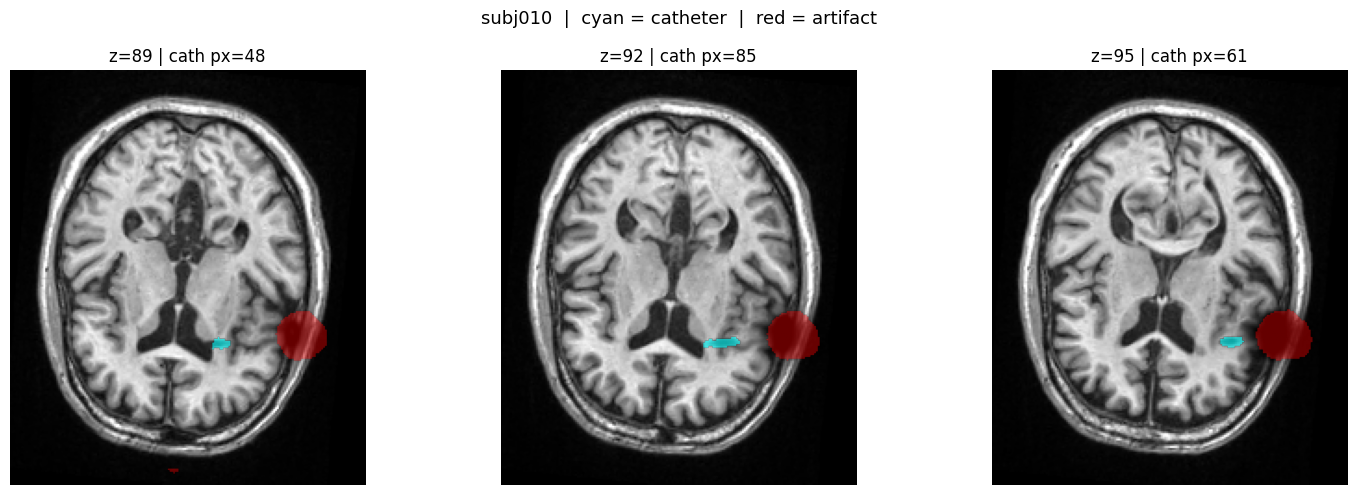

In [37]:
import matplotlib.pyplot as plt

VIS_SUBJECT_B = 'subj010'

# Load all three from native space
img_nib  = nib.load(str(ORIGINAL_DATA_DIR / VIS_SUBJECT_B / f'{VIS_SUBJECT_B}_image.nii.gz'))
cath_nib = nib.load(str(VIS_DIR_B  / f'{VIS_SUBJECT_B}_taskB.nii.gz'))
art_nib  = nib.load(str(PRED_DIR_A / f'{VIS_SUBJECT_B}_taskA.nii.gz'))

# Check affines match
print("img affine matches cath:", np.allclose(img_nib.affine, cath_nib.affine, atol=1e-3))
print("img affine matches art: ", np.allclose(img_nib.affine, art_nib.affine,  atol=1e-3))
print(f"img:{img_nib.shape}  cath:{cath_nib.shape}  art:{art_nib.shape}")

art_resampled = resample_from_to(art_nib, img_nib, order=0)
img_vol      = img_nib.get_fdata()
cath_vol     = cath_nib.get_fdata()
artifact_vol = art_resampled.get_fdata()

print(f"img:{img_vol.shape}  cath:{cath_vol.shape}  art:{artifact_vol.shape}")  # should all match now
# Find best slice: most catheter foreground
fg_per_slice = cath_vol.sum(axis=(0, 1))
if fg_per_slice.max() > 0:
    best_z = int(fg_per_slice.argmax())
    slices = [max(0, best_z - 3), best_z, min(img_vol.shape[2] - 1, best_z + 3)]
else:
    mid = img_vol.shape[2] // 2
    slices = [mid - 10, mid, mid + 10]
    print('Warning: no catheter foreground found in prediction!')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'{VIS_SUBJECT_B}  |  cyan = catheter  |  red = artifact', fontsize=13)

vmin, vmax = np.percentile(img_vol, [1, 99])
for ax, z in zip(axes, slices):
    ax.imshow(img_vol[:, :, z].T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

    cath_overlay = np.zeros((*cath_vol[:, :, z].T.shape, 4))
    cath_overlay[cath_vol[:, :, z].T > 0] = [0, 1, 1, 0.6]
    ax.imshow(cath_overlay, origin='lower')

    art_overlay = np.zeros((*artifact_vol[:, :, z].T.shape, 4))
    art_overlay[artifact_vol[:, :, z].T > 0] = [1, 0, 0, 0.4]
    ax.imshow(art_overlay, origin='lower')

    ax.set_title(f'z={z} | cath px={int(cath_vol[:,:,z].sum())}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(PRED_DIR_B / f'{VIS_SUBJECT_B}_taskB_vis.png', dpi=150)
plt.show()

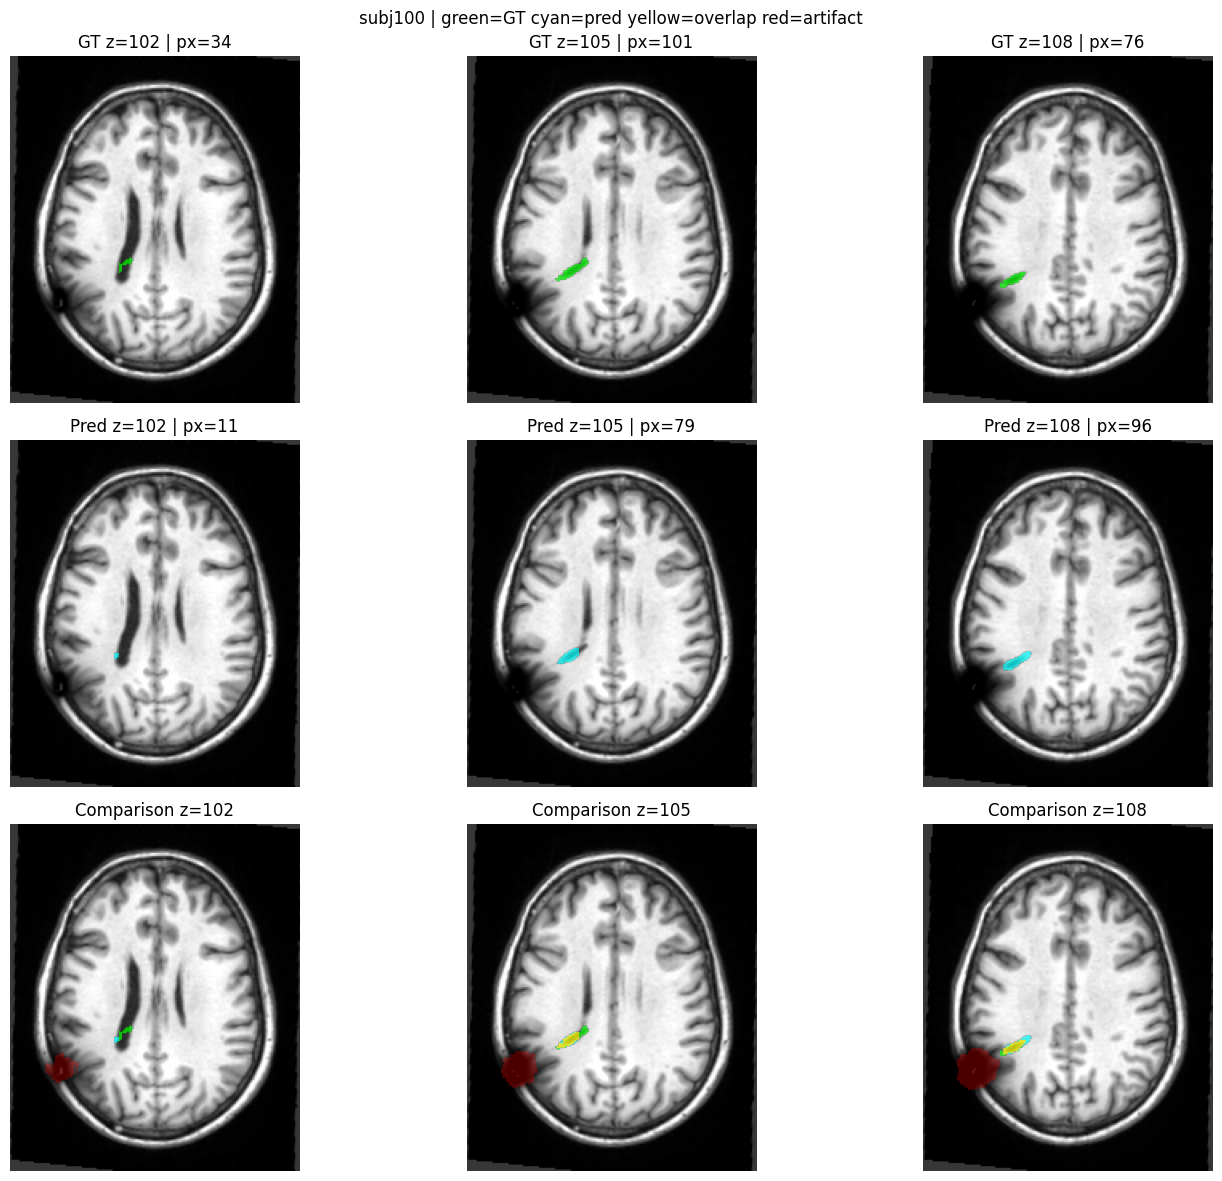

In [46]:
import matplotlib.pyplot as plt
from nibabel.processing import resample_from_to

VIS_SUBJECT_B = 'subj100'  # must be a val subject (has GT + was seen during val)

# Load image, ground truth catheter, and GT artifact
img_nib = nib.load(str(TRAIN_DATA_DIR / VIS_SUBJECT_B / f'{VIS_SUBJECT_B}_image_preprocessed.nii.gz'))
gt_cath_nib = nib.load(str(TRAIN_DATA_DIR / VIS_SUBJECT_B / f'{VIS_SUBJECT_B}_image_catheter.nii.gz'))
gt_art_nib  = nib.load(str(TRAIN_DATA_DIR / VIS_SUBJECT_B / f'{VIS_SUBJECT_B}_image_artifact.nii.gz'))

img_vol  = img_nib.get_fdata()
gt_cath  = gt_cath_nib.get_fdata()
gt_cath  = (gt_cath == 1).astype(np.uint8)  # visible catheter only
gt_art   = gt_art_nib.get_fdata().astype(np.uint8)

# Run inference on this subject to get a prediction
img_t = test_pre(str(TRAIN_DATA_DIR / VIS_SUBJECT_B / f'{VIS_SUBJECT_B}_image_preprocessed.nii.gz')).unsqueeze(0).to(device)
model_B.eval()
with torch.no_grad():
    logits = sliding_window_inference(img_t, PATCH_SIZE, SW_BATCH_SIZE, model_B, overlap=OVERLAP)
pred_np = logits.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)
pred_np = keep_largest_component(pred_np)

# Resize pred back to native shape
from scipy.ndimage import zoom as ndzoom
if pred_np.shape != img_vol.shape:
    zf = [img_vol.shape[i] / pred_np.shape[i] for i in range(3)]
    pred_vol = ndzoom(pred_np, zf, order=0).astype(np.uint8)
else:
    pred_vol = pred_np

# Find best slice from ground truth
fg_per_slice = gt_cath.sum(axis=(0, 1))
best_z = int(fg_per_slice.argmax()) if fg_per_slice.max() > 0 else img_vol.shape[2] // 2
slices = [max(0, best_z - 3), best_z, min(img_vol.shape[2] - 1, best_z + 3)]

# Plot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f'{VIS_SUBJECT_B} | green=GT cyan=pred yellow=overlap red=artifact', fontsize=12)
vmin, vmax = np.percentile(img_vol, [1, 99])

for col, z in enumerate(slices):
    mri  = img_vol[:, :, z].T
    gt   = gt_cath[:, :, z].T
    pred = pred_vol[:, :, z].T
    art  = gt_art[:, :, z].T

    # Row 0: Ground truth
    axes[0, col].imshow(mri, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    ov = np.zeros((*gt.shape, 4)); ov[gt > 0] = [0, 1, 0, 0.7]
    axes[0, col].imshow(ov, origin='lower')
    axes[0, col].set_title(f'GT z={z} | px={int(gt.sum())}'); axes[0, col].axis('off')

    # Row 1: Prediction
    axes[1, col].imshow(mri, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    ov = np.zeros((*pred.shape, 4)); ov[pred > 0] = [0, 1, 1, 0.7]
    axes[1, col].imshow(ov, origin='lower')
    axes[1, col].set_title(f'Pred z={z} | px={int(pred.sum())}'); axes[1, col].axis('off')

    # Row 2: Comparison — green=missed, cyan=FP, yellow=correct, red=artifact
    axes[2, col].imshow(mri, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    ov = np.zeros((*gt.shape, 4))
    ov[(gt > 0) & (pred == 0)] = [0, 1, 0, 0.7]   # missed
    ov[(pred > 0) & (gt == 0)] = [0, 1, 1, 0.7]   # false positive
    ov[(gt > 0) & (pred > 0)]  = [1, 1, 0, 0.7]   # correct
    axes[2, col].imshow(ov, origin='lower')
    art_ov = np.zeros((*art.shape, 4)); art_ov[art > 0] = [1, 0, 0, 0.3]
    axes[2, col].imshow(art_ov, origin='lower')
    axes[2, col].set_title(f'Comparison z={z}'); axes[2, col].axis('off')

axes[0, 0].set_ylabel('Ground Truth', fontsize=11)
axes[1, 0].set_ylabel('Prediction', fontsize=11)
axes[2, 0].set_ylabel('Comparison', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR_B / f'{VIS_SUBJECT_B}_comparison.png', dpi=150)
plt.show()